Zero-Shot Prompting with LangChain

    Directly ask the LLM a question without examples.

In [47]:
from langchain_openai import ChatOpenAI
from langchain.prompts import ChatPromptTemplate

llm = ChatOpenAI(model="gpt-4o", temperature=0)

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are an automotive diagnostic assistant."),
    ("human", "Diagnose the issue: Engine temperature is rising rapidly despite normal coolant levels.")
])

response = llm.invoke(prompt.format_messages())
print(response.content)

If the engine temperature is rising rapidly despite normal coolant levels, there are several potential issues to consider:

1. **Thermostat Malfunction**: The thermostat regulates the flow of coolant between the engine and the radiator. If it is stuck closed, it can prevent coolant from circulating properly, causing the engine to overheat.

2. **Radiator Issues**: The radiator may be clogged or have a blockage, preventing proper heat dissipation. Additionally, external debris or damage to the radiator fins can reduce its efficiency.

3. **Water Pump Failure**: The water pump is responsible for circulating coolant throughout the engine. If it is failing or has a broken impeller, it may not be moving coolant effectively.

4. **Cooling Fan Problems**: Electric or mechanical cooling fans help maintain the radiator's temperature. If the fan is not turning on due to a faulty fan motor, relay, or temperature sensor, the engine can overheat.

5. **Air in the Cooling System**: Air pockets can f

Few-Shot Prompting with LangChain

    Provide examples to teach the model the pattern.


In [26]:
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are an automotive diagnostic assistant."),
    ("human",
    "Example 1:\nInput: Engine makes clicking sound\nOutput: Battery issue likely.\n\n" +
    "Example 2:\nInput: Brakes squealing\nOutput: Brake pad wear.\n\n" +
    "New Input: Engine temperature rising despite coolant levels\nOutput:")
])

response = llm.invoke(prompt.format_messages())
print(response.content)

Thermostat malfunction or radiator issue.


Chain-of-Thought Prompting (CoT)

    Force the model to reason step by step.

In [27]:
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are an automotive diagnostic assistant. Think step by step."),
    ("human", "Diagnose this issue: Engine temperature is rising rapidly despite normal coolant levels.")
])

response = llm.invoke(prompt.format_messages())
print(response.content)

When the engine temperature is rising rapidly despite normal coolant levels, it indicates that there might be an issue with the cooling system or related components. Here are some steps to diagnose the problem:

1. **Check the Thermostat:**
   - The thermostat regulates the flow of coolant between the engine and the radiator. If it is stuck closed, it can prevent coolant from circulating properly, causing the engine to overheat.
   - To test, you can remove the thermostat and place it in hot water to see if it opens. If it doesn't, it needs to be replaced.

2. **Inspect the Radiator:**
   - Ensure that the radiator is not clogged or blocked. Debris or corrosion can restrict coolant flow.
   - Check for any visible leaks or damage to the radiator.

3. **Examine the Water Pump:**
   - The water pump is responsible for circulating coolant throughout the engine. If it fails, coolant will not circulate, leading to overheating.
   - Look for signs of leakage around the water pump or listen f

Structured Prompting

    Use JSON or structured outputs for API-readiness.

In [28]:
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are an automotive diagnostic assistant. Respond in JSON format."),
    ("human", "Input: Engine temperature is rising rapidly despite normal coolant levels.")
])

response = llm.invoke(prompt.format_messages())
print(response.content)

```json
{
  "possible_causes": [
    {
      "cause": "Thermostat Failure",
      "description": "The thermostat may be stuck closed, preventing coolant from circulating through the engine."
    },
    {
      "cause": "Water Pump Malfunction",
      "description": "The water pump may not be functioning properly, leading to inadequate coolant flow."
    },
    {
      "cause": "Radiator Blockage",
      "description": "There could be a blockage in the radiator preventing proper heat dissipation."
    },
    {
      "cause": "Cooling Fan Issue",
      "description": "The cooling fan may not be operating correctly, reducing airflow through the radiator."
    },
    {
      "cause": "Air in the Cooling System",
      "description": "Air pockets in the cooling system can prevent proper coolant circulation."
    },
    {
      "cause": "Head Gasket Leak",
      "description": "A head gasket leak can cause combustion gases to enter the cooling system, leading to overheating."
    }
  ],
  "r

Plan-and-Execute with LangGraph

        Use LangGraph to create a workflow: Plan first, then execute steps.

        Multi-Agent with Function Calling in LangGraph
    1.	Define your State schema, including messages and outputs.
    2.	Create nodes for each step (e.g. query decomposition, call function, response).
    3.	Use LLM agents with function-calling tools inside those nodes.
    4.	Connect nodes in a graph, compile and invoke.

In [36]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from langchain_openai import ChatOpenAI

# Define State
class State(TypedDict):
    messages: list
    function_response: str
    final_response: str

# Build the graph
builder = StateGraph(State)

llm = ChatOpenAI(model="gpt-4o", temperature=0)

# Node 1: Agent processes the question and plans
def plan_node(state: State):
    prompt = "You are an assistant. Plan to compare vehicles and call function 'get_specs'."
    r = llm.invoke(prompt)
    state["messages"] = [r]  # store reasoning
    return state

# Node 2: Call the spec-fetching function (tool)
def fetch_specs_node(state: State):
    # Simulate calling external function
    state["function_response"] = '{"Maybach":"770Nm","Audi":"720Nm"}'
    return state

# Node 3: Summarize final answer using both reasoning + function output
def response_node(state: State):
    prompt = f"{state['messages'][0].content}\nFunction result: {state['function_response']}\nNow compose the final answer."
    r = llm.invoke(prompt)
    state["final_response"] = r.content
    return state

# Add these nodes and connect
builder.add_node("Plan", plan_node)
builder.add_node("Fetch", fetch_specs_node)
builder.add_node("Respond", response_node)

builder.set_entry_point("Plan")
builder.add_edge("Plan", "Fetch")
builder.add_edge("Fetch", "Respond")
builder.set_finish_point("Respond")

graph = builder.compile()
result = graph.invoke({"messages": [], "function_response": "", "final_response": ""})

print(result["final_response"])

To effectively compare vehicles using the `get_specs` function, follow these steps to ensure a comprehensive analysis:

1. **Identify Vehicles for Comparison:**
   - Choose the vehicles you want to compare by specifying their make, model, and year. For example, you might want to compare a 2022 Toyota Camry with a 2022 Honda Accord.

2. **Gather Vehicle Specifications:**
   - Use the `get_specs` function to retrieve detailed specifications for each vehicle. This function should provide information such as engine type, horsepower, torque, fuel efficiency, dimensions, safety features, and more.

   ```python
   vehicle1_specs = get_specs(make="Toyota", model="Camry", year=2022)
   vehicle2_specs = get_specs(make="Honda", model="Accord", year=2022)
   ```

3. **Organize the Data:**
   - Structure the gathered data in a way that makes it easy to compare. You can use a table or a list to display key features side by side.

4. **Compare Key Features:**
   - Focus on comparing essential specif

•	Explicit function-calling happens inside a node (e.g. fetch_specs_node).
•	You can integrate real API calls there—open design.
•	Final response node can weave together reasoning and tool output.

Agentic AI Python Script for Automotive Feature Extraction

In [37]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain.chains import LLMChain
import json

# Set your OpenAI API Key in environment or use openai.api_key = "your-key"
llm = ChatOpenAI(model="gpt-4o")

In [38]:
# Sample semi-structured text (brochure extract)
brochure_text = """
The Mercedes-Maybach GLS 600 4MATIC Night Series comes with an advanced V8 engine of 3,982 cc generating 770 Nm torque.
Its fuel type is Super (Petrol) with a mild hybrid system. The car measures 5208 mm in length, 2157 mm in width, and 1838 mm in height.
Combined fuel consumption is 20.5 mpg and CO2 emissions are 313 g/km. The price is £206,350.
Weight: Kerb Weight is 2,825 kg, and Gross Vehicle Weight is 3,270 kg.
Additional features include Part Assist, Ambient Lighting (64 colors), Multicontour Massage Seats, and the Warmth Comfort Package.
Suspension is AIRMATIC Air Suspension for both front and rear.
"""

In [39]:
# Define the extraction prompt
prompt_template = ChatPromptTemplate.from_template("""
Extract the following vehicle features from the given text and return as JSON:
- Torque
- Engine Capacity
- CO2 Emissions
- Price
- Fuel Type
- Fuel Consumption (Combined)
- Suspension
- Ambient Lighting

Text: {brochure_text}

Respond only with valid JSON output.
""")

In [40]:
# Set up the LangChain pipeline
chain = LLMChain(llm=llm, prompt=prompt_template)

# Invoke the chain
result = chain.invoke({"brochure_text": brochure_text})

# Print the extracted features
print("Extracted Vehicle Features:\n")
print(result['text'])

/var/folders/j9/t7f_l7rd20101rcpcynrvqyh0000gn/T/ipykernel_29550/3484892476.py:2: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  chain = LLMChain(llm=llm, prompt=prompt_template)


Extracted Vehicle Features:

```json
{
  "Torque": "770 Nm",
  "Engine Capacity": "3,982 cc",
  "CO2 Emissions": "313 g/km",
  "Price": "£206,350",
  "Fuel Type": "Super (Petrol)",
  "Fuel Consumption (Combined)": "20.5 mpg",
  "Suspension": "AIRMATIC Air Suspension",
  "Ambient Lighting": "64 colors"
}
```


Multi-Agent Workflow Would Work Using AutoGen

    AutoGen is an LLM-based multi-agent framework 
    that allows multiple AI agents (LLMs, tools, humans) 
    to collaborate autonomously.

Goal: 
    Automate Mercedes-Maybach GLS 600 spec extraction, structuring, and decision-making.

    Agent	                Role
    Data Extractor Agent ->	Extract specs from unstructured text
    Data Structurer Agent ->	Merge data into structured JSON/CSV
    Decision Assistant Agent -> Provide recommendations & generate summary

Step 1. Define the Agents

    AutoGen Agent Types:

    Agent	    AutoGen Type	    Purpose
    Data Extractor	AssistantAgent	Extract specs from text
    Data Structurer	AssistantAgent or FunctionAgent	Merge outputs
    Decision Assistant	AssistantAgent	Generate recommendations

Step 2️. Install AutoGen
    pip install autogen

Step 3. AutoGen Configuration

•	Define system prompts for each agent.
•	Use AssistantAgent with specialized roles.
•	Optionally add UserProxyAgent to simulate human interaction or review.

Step 4. Create AutoGen Multi-Agent Setup

In [44]:
from autogen import AssistantAgent, UserProxyAgent, GroupChat, GroupChatManager
import os

# LLM config
config = {
    "model": "gpt-4o",
    "api_key": os.getenv("OPENAI_API_KEY")
}


# Define agents
extractor = AssistantAgent(
    name="Extractor",
    system_message="You are a data extractor. Extract vehicle specs like Torque, Engine, CO2, Price from input text and return JSON.",
    llm_config=config
)

structurer = AssistantAgent(
    name="Structurer",
    system_message="You are a data structurer. Merge multiple extracted JSONs into a single complete JSON output.",
    llm_config=config
)

decision_maker = AssistantAgent(
    name="DecisionAssistant",
    system_message="You are a decision assistant. Given vehicle specs, generate a human-friendly summary and recommend upsells or comparisons.",
    llm_config=config
)

user = UserProxyAgent(
    name="User",
    code_execution_config={
        "use_docker": False },
    human_input_mode="NEVER",  # Simulates user
    max_consecutive_auto_reply=2
)

# Define group chat
group_chat = GroupChat(
    agents=[user, extractor, structurer, decision_maker],
    messages=[]
)

manager = GroupChatManager(group_chat, llm_config=config)

Step 5️⃣ Run the AutoGen Multi-Agent Pipeline

In [45]:
# Simulated brochure text
brochure_text = """
The Mercedes-Maybach GLS 600 4MATIC Night Series comes with an advanced V8 engine of 3,982 cc generating 770 Nm torque.
Fuel type is Super (Petrol) with mild hybrid system. Dimensions are 5208 x 2157 x 1838 mm.
Combined fuel consumption is 20.5 mpg, CO2 emissions are 313 g/km, price is £206,350.
Weight: 2,825 kg. Features include Part Assist, 64-color Ambient Lighting, and AIRMATIC Suspension.
"""

# Start the agent conversation
user.initiate_chat(
    manager,
    message=f"Please process this vehicle brochure text:\n{brochure_text}"
)

User (to chat_manager):

Please process this vehicle brochure text:

The Mercedes-Maybach GLS 600 4MATIC Night Series comes with an advanced V8 engine of 3,982 cc generating 770 Nm torque.
Fuel type is Super (Petrol) with mild hybrid system. Dimensions are 5208 x 2157 x 1838 mm.
Combined fuel consumption is 20.5 mpg, CO2 emissions are 313 g/km, price is £206,350.
Weight: 2,825 kg. Features include Part Assist, 64-color Ambient Lighting, and AIRMATIC Suspension.


--------------------------------------------------------------------------------

Next speaker: Extractor

Extractor (to chat_manager):

```json
{
  "Vehicle": "Mercedes-Maybach GLS 600 4MATIC Night Series",
  "Engine": "V8, 3,982 cc",
  "Torque": "770 Nm",
  "Fuel Type": "Super (Petrol) with mild hybrid system",
  "CO2 Emissions": "313 g/km",
  "Price": "£206,350"
}
```

--------------------------------------------------------------------------------

Next speaker: User


>>>>>>>> EXECUTING CODE BLOCK 0 (inferred language is 

ChatResult(chat_id=None, chat_history=[{'content': 'Please process this vehicle brochure text:\n\nThe Mercedes-Maybach GLS 600 4MATIC Night Series comes with an advanced V8 engine of 3,982 cc generating 770 Nm torque.\nFuel type is Super (Petrol) with mild hybrid system. Dimensions are 5208 x 2157 x 1838 mm.\nCombined fuel consumption is 20.5 mpg, CO2 emissions are 313 g/km, price is £206,350.\nWeight: 2,825 kg. Features include Part Assist, 64-color Ambient Lighting, and AIRMATIC Suspension.\n', 'role': 'assistant', 'name': 'User'}, {'content': '```json\n{\n  "Vehicle": "Mercedes-Maybach GLS 600 4MATIC Night Series",\n  "Engine": "V8, 3,982 cc",\n  "Torque": "770 Nm",\n  "Fuel Type": "Super (Petrol) with mild hybrid system",\n  "CO2 Emissions": "313 g/km",\n  "Price": "£206,350"\n}\n```', 'name': 'Extractor', 'role': 'user'}, {'content': 'exitcode: 1 (execution failed)\nCode output: \nunknown language json', 'role': 'assistant', 'name': 'User'}, {'content': '', 'role': 'assistant', 'n

AutoGen Multi-Agent Flow:

    Step	Agent
    1	User sends brochure text to Extractor Agent
    2	Extractor Agent extracts specs (Torque, Engine, etc.)
    3	Sends extracted data to Structurer Agent
    4	Structurer Agent merges and cleans data
    5	Passes structured data to Decision Assistant Agent
    6	Decision Assistant Agent generates recommendations
    7	Final output is shared back to User Proxy Agent

Step 7 Output Example

    Extractor Output:
    {
    "Vehicle Name": "Mercedes-Maybach GLS 600",
    "Torque": "770 Nm",
    "Engine Capacity": "3,982 cc V8",
    "CO2 Emissions": "313 g/km",
    "Price": "£206,350",
    "Fuel Type": "Super, Mild Hybrid",
    "Fuel Consumption": "20.5 mpg",
    "Dimensions": "5208 x 2157 x 1838 mm",
    "Weight": "2825 kg",
    "Suspension": "AIRMATIC",
    "Ambient Lighting": "64 Colors"
    }

Decision Assistant Output:

    Summary:
    The Maybach GLS 600 offers premium V8 performance and hybrid efficiency.

    Recommendations:
    - Upsell: Offer luxury concierge package.
    - CO2 313 g/km: Recommend hybrid alternatives for eco-sensitive customers.
    - Compare against Rolls Royce Cullinan for ultra-luxury buyers.

Key Benefits of Using AutoGen


    Feature	        AutoGen         Advantage
    Multi-Agent Collaboration	Agents specialize in different roles
    Conversation Memory	Each agent remembers the flow
    Easy Orchestration	No manual pipeline management
    Human-in-the-loop	Optional via UserProxyAgent

Step 1: Define State

In [48]:
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI

# Define graph state
class State(TypedDict):
    messages: Annotated[list, add_messages]
    data: dict
    chart_path: str
    summary: str
    report: str

Step 2: Build the Graph


In [49]:
builder = StateGraph(State)

Step 3: Create Nodes

    Data Ingestion Node

In [ ]:
# LLM config
llm = ChatOpenAI(model="gpt-4o", temperature=0.0)

def ingest_data(state: State) -> dict:
    state["data"] = {"Model": ["SUV", "Sedan"], "Sales": [500,300], "CO2":[313,180]}
    return state

#Chart Generator Node (Visualization)

def chart_gen(state: State) -> dict:
    import matplotlib.pyplot as plt
    import pandas as pd
    df = pd.DataFrame(state["data"])
    plt.figure(figsize=(6,4))
    plt.bar(df["Model"], df["CO2"])
    path = "co2_chart.png"
    plt.savefig(path); plt.close()
    state["chart_path"] = path
    return state


#Summarization Node (LLM Summary)


def llm_summarizer(state: State) -> dict:
    prompt = f"Data: {state['data']}. Chart: {state['chart_path']}."
    response = llm.invoke(prompt)
    state["summary"] = response.content
    return state

#Report Generation Node

def report_writer(state: State) -> dict:
    with open("report.txt","w") as f:
        f.write(state["summary"] + f"\nSee chart {state['chart_path']}")
    state["report"] = "report.txt"
    return state

In [ ]:
# Connect the Graph

# Add nodes to graph
builder.add_node("IngestData", ingest_data)
builder.add_node("ChartGen", chart_gen)
builder.add_node("Summarizer", llm_summarizer)
builder.add_node("ReportWriter", report_writer)

builder.set_entry_point("IngestData")
builder.add_edge("IngestData", "ChartGen")
builder.add_edge("ChartGen", "Summarizer")
builder.add_edge("Summarizer", "ReportWriter")
builder.set_finish_point("ReportWriter")

In [ ]:
# Compile & Run

graph = builder.compile()
result = graph.invoke({})
print("Report generated at:", result["report"])

Report generated at: report.txt


What You Get Now:
1️⃣ Chart
•	Saved as co2_chart.png
•	Displayed inline if you’re in Jupyter / Colab / Streamlit
2️⃣ Executive Summary
•	Auto-generated by GPT-4o based on data + chart context

3️⃣ Final Report
•	executive_report.txt includes summary and chart path

Visual Workflow Summary

    [ Ingest Data ]
            ↓
    [ Generate Chart + Display Visualization ]
            ↓
    [ LLM Summary (GPT-4o) ]
            ↓
    [ Write Report + Save Paths ]

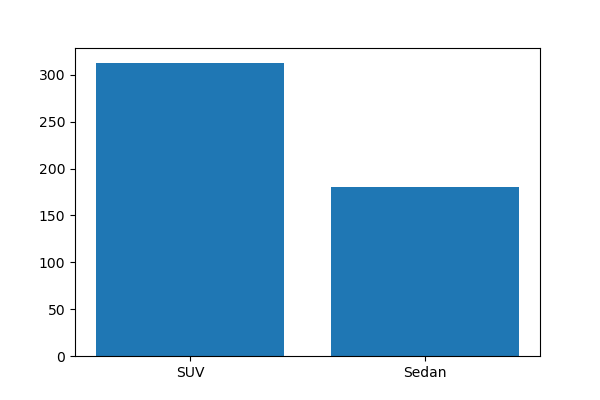

In [16]:
from IPython.display import Image, display
display(Image("co2_chart.png"))

Benefits of LangGraph Approach

•	Visual & Narrative Automation
•	Faster Leadership Decisions
•	Reusable AI Pipelines
•	Scalable for Automotive Data

Automotive Applications

    •	Executive Briefings
    •	CO₂ Compliance Dashboards
    •	Vehicle Feature Comparisons
    •	Sales Strategy Recommendations

In [17]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from langchain_openai import ChatOpenAI
import pandas as pd
import json

# Define state
class State(TypedDict):
    specs: dict
    comparison_data: dict
    comparison_table: str
    insights: str
    report: str

# Initialize graph
builder = StateGraph(State)

# Step 1: Extracted Specs Node (Simulated Input)
def extract_specs(state: State):
    state["specs"] = {
        "Model": "Maybach GLS 600",
        "Torque": "770 Nm",
        "CO2": "313 g/km",
        "Price": "£206,350",
        "Features": ["Massage Seats", "Ambient Lighting", "AIRMATIC Suspension"]
    }
    return state

# Step 2: Prepare Comparison Table Node
def prepare_comparison(state: State):
    competitors = pd.DataFrame({
        "Model": ["Maybach GLS 600", "BMW X7", "Range Rover Autobiography"],
        "Torque (Nm)": [770, 750, 700],
        "CO2 (g/km)": [313, 295, 288],
        "Price (£)": [206350, 130000, 140000]
    })
    state["comparison_data"] = competitors.to_dict()
    state["comparison_table"] = competitors.to_string(index=False)
    return state

# Step 3: Auto-Generate Insights using GPT-4o
llm = ChatOpenAI(model="gpt-4o")

def generate_insights(state: State):
    prompt = f"""
Compare the Maybach GLS 600 to competitors using the table below:
{state['comparison_table']}
Highlight performance, emissions, and upselling points.
"""
    state["insights"] = llm.invoke(prompt).content
    return state

# Step 4: Generate Final Report Node
def generate_report(state: State):
    report_text = "--- Vehicle Comparison Report ---\n"
    report_text += state["comparison_table"] + "\n\n"
    report_text += "--- Auto-Generated Insights ---\n"
    report_text += state["insights"]
    with open("vehicle_comparison_report.txt", "w") as f:
        f.write(report_text)
    state["report"] = "vehicle_comparison_report.txt"
    return state

# Add nodes
builder.add_node("ExtractSpecs", extract_specs)
builder.add_node("PrepareComparison", prepare_comparison)
builder.add_node("GenerateInsights", generate_insights)
builder.add_node("GenerateReport", generate_report)

# Define edges
builder.set_entry_point("ExtractSpecs")
builder.add_edge("ExtractSpecs", "PrepareComparison")
builder.add_edge("PrepareComparison", "GenerateInsights")
builder.add_edge("GenerateInsights", "GenerateReport")
builder.set_finish_point("GenerateReport")

# Compile and run
graph = builder.compile()
result = graph.invoke({})

print("Generated Report Path:", result["report"])

# Optional: Display the report content
with open(result["report"], "r") as f:
    print(f.read())

Generated Report Path: vehicle_comparison_report.txt
--- Vehicle Comparison Report ---
                    Model  Torque (Nm)  CO2 (g/km)  Price (£)
          Maybach GLS 600          770         313     206350
                   BMW X7          750         295     130000
Range Rover Autobiography          700         288     140000

--- Auto-Generated Insights ---
Here's a comparison of the Maybach GLS 600 with the BMW X7 and the Range Rover Autobiography based on performance, emissions, and pricing.

### Performance (Torque)
- **Maybach GLS 600**: 770 Nm
  - The Maybach GLS 600 leads in torque, offering superior pulling power and acceleration, which enhances both performance and driving experience.

- **BMW X7**: 750 Nm
  - The BMW X7 is close in performance to the Maybach, providing strong torque and dynamic driving capabilities.

- **Range Rover Autobiography**: 700 Nm
  - The Range Rover provides ample torque, though it is the lowest among the three, yet it remains competitive in 

In [18]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from langchain_openai import ChatOpenAI
import pandas as pd
import matplotlib.pyplot as plt
import json

# Define state
class State(TypedDict):
    specs: dict
    comparison_data: dict
    comparison_table: str
    chart_path: str
    insights: str
    report: str

# Initialize graph
builder = StateGraph(State)

# Step 1: Extracted Specs Node (Simulated Input)
def extract_specs(state: State):
    state["specs"] = {
        "Model": "Maybach GLS 600",
        "Torque": "770 Nm",
        "CO2": "313 g/km",
        "Price": "£206,350",
        "Features": ["Massage Seats", "Ambient Lighting", "AIRMATIC Suspension"]
    }
    return state

# Step 2: Prepare Comparison Table and Visualization
def prepare_comparison(state: State):
    competitors = pd.DataFrame({
        "Model": ["Maybach GLS 600", "BMW X7", "Range Rover Autobiography"],
        "Torque (Nm)": [770, 750, 700],
        "CO2 (g/km)": [313, 295, 288],
        "Price (£)": [206350, 130000, 140000]
    })
    state["comparison_data"] = competitors.to_dict()
    state["comparison_table"] = competitors.to_string(index=False)

    # Generate Visualization
    plt.figure(figsize=(8,5))
    plt.bar(competitors['Model'], competitors['Torque (Nm)'], label='Torque (Nm)', alpha=0.6)
    plt.plot(competitors['Model'], competitors['CO2 (g/km)'], color='red', marker='o', label='CO2 (g/km)')
    plt.ylabel("Torque / CO2")
    plt.title("Torque and CO2 Comparison")
    plt.legend()
    chart_path = "comparison_chart.png"
    plt.savefig(chart_path)
    plt.close()

    state["chart_path"] = chart_path
    return state

# Step 3: Auto-Generate Insights using GPT-4o
llm = ChatOpenAI(model="gpt-4o")

def generate_insights(state: State):
    prompt = f"""
Compare the Maybach GLS 600 to competitors using the table below:
{state['comparison_table']}
Also consider the chart saved at {state['chart_path']}.
Highlight performance, emissions, and upselling points.
"""
    state["insights"] = llm.invoke(prompt).content
    return state

# Step 4: Generate Final Report Node
def generate_report(state: State):
    report_text = "--- Vehicle Comparison Report ---\n"
    report_text += state["comparison_table"] + "\n\n"
    report_text += "--- Auto-Generated Insights ---\n"
    report_text += state["insights"] + "\n\n"
    report_text += f"See attached chart: {state['chart_path']}"
    with open("vehicle_comparison_report.txt", "w") as f:
        f.write(report_text)
    state["report"] = "vehicle_comparison_report.txt"
    return state

# Add nodes
builder.add_node("ExtractSpecs", extract_specs)
builder.add_node("PrepareComparison", prepare_comparison)
builder.add_node("GenerateInsights", generate_insights)
builder.add_node("GenerateReport", generate_report)

# Define edges
builder.set_entry_point("ExtractSpecs")
builder.add_edge("ExtractSpecs", "PrepareComparison")
builder.add_edge("PrepareComparison", "GenerateInsights")
builder.add_edge("GenerateInsights", "GenerateReport")
builder.set_finish_point("GenerateReport")

# Compile and run
graph = builder.compile()
result = graph.invoke({})

print("Generated Report Path:", result["report"])



Generated Report Path: vehicle_comparison_report.txt


--- Vehicle Comparison Report ---
                    Model  Torque (Nm)  CO2 (g/km)  Price (£)
          Maybach GLS 600          770         313     206350
                   BMW X7          750         295     130000
Range Rover Autobiography          700         288     140000

--- Auto-Generated Insights ---
Based on the data provided and assuming typical characteristics of these vehicles, here's a comparison of the Maybach GLS 600 with its competitors, focusing on performance, emissions, and upselling points:

### Performance
- **Torque:**
  - **Maybach GLS 600:** 770 Nm
  - **BMW X7:** 750 Nm
  - **Range Rover Autobiography:** 700 Nm
  
  The Maybach GLS 600 offers the highest torque among the three, suggesting superior performance in terms of acceleration and pulling power, especially noteworthy for a luxury SUV of its class.

### Emissions
- **CO2 Emissions:**
  - **Maybach GLS 600:** 313 g/km
  - **BMW X7:** 295 g/km
  - **Range Rover Autobiography:** 288 g/km

  The Maybach 

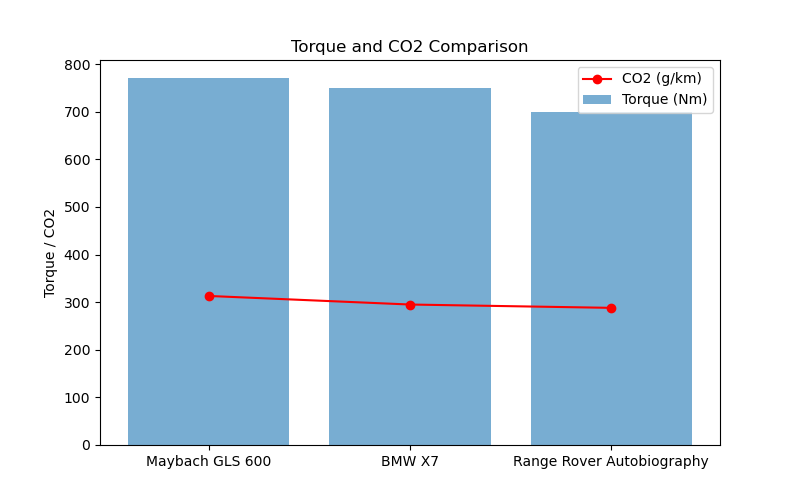

In [19]:
# Optional: Display the report content and chart
from IPython.display import Image, display

with open(result["report"], "r") as f:
    print(f.read())

display(Image(result["chart_path"]))

In [22]:
%%writefile auto_generated_dashboard.py

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

# Simulated agent-extracted data
data = {
    'Model': ['Maybach GLS 600', 'Audi Q6 e-tron'],
    'Torque (Nm)': [770, 720],
    'CO2 (g/km)': [313, 0],
    'Price (£)': [206350, 85000],
    'Fuel Type': ['Mild Hybrid Petrol', 'Electric']
}

df = pd.DataFrame(data)

# Title
st.title("Auto-Generated Vehicle Comparison Dashboard")

# Display table
st.subheader("Extracted Vehicle Specs")
st.dataframe(df)

# Bar Chart: Torque & CO2 Comparison
st.subheader("Torque vs CO₂ Emissions")
fig, ax1 = plt.subplots()

ax1.bar(df['Model'], df['Torque (Nm)'], label='Torque (Nm)', alpha=0.6)
ax2 = ax1.twinx()
ax2.plot(df['Model'], df['CO2 (g/km)'], color='red', marker='o', label='CO₂ (g/km)')

ax1.set_ylabel("Torque (Nm)")
ax2.set_ylabel("CO₂ (g/km)")

fig.legend(loc='upper right')
st.pyplot(fig)

# Price Comparison
st.subheader("Price Comparison")
st.bar_chart(df.set_index('Model')['Price (£)'])

# Text Insights
st.subheader("Auto-Generated Insights")
for idx, row in df.iterrows():
    if row['CO2 (g/km)'] == 0:
        eco_note = "Eco-Friendly (Electric)"
    else:
        eco_note = "Higher Emissions"
    st.write(f"**{row['Model']}**: {row['Fuel Type']}, {eco_note}, Price: £{row['Price (£)']}")

Overwriting auto_generated_dashboard.py


In [23]:
%%writefile vehicle_dashboard.py

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

# Simulated agent-extracted data
data = {
    'Model': ['Maybach GLS 600', 'Audi Q6 e-tron'],
    'Torque (Nm)': [770, 720],
    'CO2 (g/km)': [313, 0],
    'Price (£)': [206350, 85000],
    'Fuel Type': ['Mild Hybrid Petrol', 'Electric']
}

df = pd.DataFrame(data)

# Title
st.title("🚗 Auto-Generated Vehicle Comparison Dashboard")

# Display Table
st.subheader("Extracted Vehicle Specs")
st.dataframe(df)

# Bar Chart: Torque vs CO₂
st.subheader("Torque vs CO₂ Emissions Comparison")
fig, ax1 = plt.subplots()

ax1.bar(df['Model'], df['Torque (Nm)'], color='blue', label='Torque (Nm)', alpha=0.6)
ax2 = ax1.twinx()
ax2.plot(df['Model'], df['CO2 (g/km)'], color='red', marker='o', label='CO₂ (g/km)')

ax1.set_ylabel("Torque (Nm)")
ax2.set_ylabel("CO₂ (g/km)")
ax1.set_xlabel("Vehicle Model")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

st.pyplot(fig)

# Price Comparison
st.subheader("Price Comparison (£)")
st.bar_chart(df.set_index('Model')['Price (£)'])

# Auto-Generated Text Insights
st.subheader("Auto-Generated Insights")
for idx, row in df.iterrows():
    eco_note = "Eco-Friendly (Electric)" if row['CO2 (g/km)'] == 0 else "Higher CO₂ Emissions"
    st.markdown(f"**{row['Model']}**: {row['Fuel Type']}, {eco_note}, Price: £{row['Price (£)']}")

Writing vehicle_dashboard.py


In [50]:
!streamlit run vehicle_dashboard.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://10.84.33.216:8501

^C
